# 复现 CALM 论文 Table 7 (Appendix C: 无数据 standardization)

**目标实验** ：CALM (kaifeng-jin) 论文 Appendix C, Table 7
- 50-node ER1, 50-node ER4, 100-node ER1
- 不做 data standardization
- 比较 CALM / GOLEM-NV-l1 / NOTEARS / PC / FGES
- 指标：CPDAG-SHD, Skeleton Precision, Skeleton Recall (mean ± std)

**本 notebook 的修改 (用户要求)**
- 样本量统一 `n = 20000` (不用论文的 1000 与 10⁶)
- `noise_ratio = 16` (CalmDataset, mode=variance；非等方差)
- 额外加入两个算法：`cd_A`、`cd_A_weakfaith`
- trials = 5

数据生成全部使用 `calm_dataset.CalmDataset` (与 CALM 论文同源)。

## 1. 环境与导入

In [1]:
import logging
import os
import sys
import time
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = print


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for path in [start, *start.parents]:
        if (path / 'calm_dataset.py').exists() and (path / 'coordinate_descent').exists():
            return path
    raise RuntimeError(f'Could not find repo root from {start}')


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
if not os.environ.get('JAVA_HOME'):
    _jdk_candidate = r'C:\Program Files\Microsoft\jdk-21.0.10.7-hotspot'
    if os.path.isdir(_jdk_candidate):
        os.environ['JAVA_HOME'] = _jdk_candidate

from MEC import find_v_structures, get_skeleton, is_in_markov_equiv_class
from calm_dataset import CalmDataset, weight_to_binary_adj
from coordinate_descent.coordinate0 import dag_coordinate_descent_l0
from coordinate_descent.cd_A_weakfaith import dag_coordinate_descent_l0_weakfaith

print('Python   :', sys.version.split()[0])
print('Repo root:', REPO_ROOT)
print('cd_A          : OK')
print('cd_A_weakfaith: OK')

c:\Users\super\DAG\experiments\notebooks\test
Python   : 3.10.11
Repo root: C:\Users\super\DAG
cd_A          : OK
cd_A_weakfaith: OK


In [2]:
# ── CALM (kaifeng-jin) ────────────────────────────────────────
CALM_REPO_CANDIDATES = [
    Path(os.environ['CALM_REPO']) if os.environ.get('CALM_REPO') else None,
    REPO_ROOT / 'external' / 'CALM',
    REPO_ROOT.parent / 'CALM',
    Path(r'D:\tmp\CALM-inspect'),
]
CALM_REPO = next(
    (p.resolve() for p in CALM_REPO_CANDIDATES
     if p is not None and (p / 'CALM.py').exists()),
    None,
)
CALM_IMPORT_ERROR = None
try:
    if CALM_REPO is None:
        raise FileNotFoundError('CALM repo not found; set $CALM_REPO or clone to external/CALM')
    if str(CALM_REPO) not in sys.path:
        sys.path.insert(0, str(CALM_REPO))
    import torch
    from CALM import calm as calm_algorithm
    HAS_CALM = True
    print(f'CALM      : OK ({CALM_REPO})')
except Exception as exc:
    HAS_CALM = False
    CALM_IMPORT_ERROR = exc
    print(f'CALM unavailable: {exc}')

# ── GOLEM-NV-l1 ───────────────────────────────────────────────
GOLEM_IMPORT_ERROR = None
try:
    _golem_src = str((REPO_ROOT / 'golemMain' / 'src').resolve())
    if _golem_src not in sys.path:
        sys.path.append(_golem_src)
    from golem import golem as golem_fit
    HAS_GOLEM = True
    print('GOLEM     : OK')
except Exception as exc:
    HAS_GOLEM = False
    GOLEM_IMPORT_ERROR = exc
    print(f'GOLEM unavailable: {exc}')

# ── NOTEARS (gcastle) ─────────────────────────────────────────
NOTEARS_IMPORT_ERROR = None
_prev_disable = logging.root.manager.disable
logging.disable(logging.INFO)
try:
    from castle.algorithms import Notears as _Notears
    HAS_NOTEARS = True
    print('NOTEARS   : OK')
except Exception as exc:
    HAS_NOTEARS = False
    NOTEARS_IMPORT_ERROR = exc
    print(f'NOTEARS unavailable: {exc}')
finally:
    logging.disable(_prev_disable)

# ── Tetrad: FGES & PC (需要 JDK 21+) ────────────────────────────
TETRAD_IMPORT_ERROR = None
try:
    import fges_compat as _tetrad_mod
    _probe = pd.DataFrame(np.eye(2), columns=['x0', 'x1'])
    _s = _tetrad_mod.TetradSearch(_probe)
    _s.set_verbose(False)
    _s.use_sem_bic()
    _s.run_fges()
    del _probe, _s
    HAS_TETRAD = True
    print('Tetrad    : OK (FGES + PC available)')
except Exception as exc:
    HAS_TETRAD = False
    TETRAD_IMPORT_ERROR = exc
    print(f'Tetrad unavailable: {exc}')

# ── CPDAG-SHD: causaldag (★ paper 用的库) > cdt > 手写 fallback ─────
CAUSALDAG_IMPORT_ERROR = None
try:
    import causaldag as _causaldag
    import igraph as _ig_for_shd
    HAS_CAUSALDAG = True
    print('causaldag : OK (★ 与论文 compute_shd_cpdag 同一实现)')
except Exception as exc:
    HAS_CAUSALDAG = False
    CAUSALDAG_IMPORT_ERROR = exc
    print(f'causaldag : MISSING ({exc})')

try:
    _toolbox = str((REPO_ROOT / 'toolbox').resolve())
    if _toolbox not in sys.path:
        sys.path.append(_toolbox)
    from cdt.metrics import SHD_CPDAG as _SHD_CPDAG
    HAS_CPDAG_SHD = True
    print('cdt.SHD_CPDAG: OK (secondary backend)')
except Exception as exc:
    _SHD_CPDAG = None
    HAS_CPDAG_SHD = False
    print(f'cdt.SHD_CPDAG: 不可用 ({exc})')

if HAS_CAUSALDAG:
    print(f'\n★ CPDAG-SHD 主路径: causaldag (与论文一致)')
elif HAS_CPDAG_SHD:
    print(f'\n⚠ CPDAG-SHD 主路径: cdt.SHD_CPDAG (近似但与论文实现不同)')
else:
    print(f'\n⚠ CPDAG-SHD 主路径: 手写 skel+v-struct 近似 (会系统性偏大 ~2.4×)')

CALM      : OK (D:\tmp\CALM-inspect)


GOLEM     : OK
NOTEARS   : OK
Tetrad    : OK (FGES + PC available)


C:\Users\super\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


causaldag : OK (★ 与论文 compute_shd_cpdag 同一实现)
cdt.SHD_CPDAG: 不可用 (No module named 'GPUtil')

★ CPDAG-SHD 主路径: causaldag (与论文一致)


## 2. 实验配置 (复现 Table 7，含用户修改)

In [3]:
CFG = {
    # ── 实验规模 ──────────────────────────────────────────
    'trials': 5,
    'seed':   42,

    # 论文 Table 7 的三个 graph 配置
    # CalmDataset: s0 = round(degree * d) 条边 → ER{k} 即 calm_degree=k
    'graph_configs': [
        {'label': '50-node ER1',  'd': 50,  'calm_degree': 1.0, 'graph_type': 'ER'},
        {'label': '50-node ER2',  'd': 50,  'calm_degree': 2.0, 'graph_type': 'ER'},
        {'label': '50-node ER4',  'd': 50,  'calm_degree': 4.0, 'graph_type': 'ER'},
        # {'label': '100-node ER1', 'd': 100, 'calm_degree': 1.0, 'graph_type': 'ER'},
    ],

    # 样本量 (用户要求统一 20000，而非论文的 1000/1e6)
    'n_samples': 50000,

    # ── 数据生成 (CalmDataset) ────────────────────────────
    'sem_type':         'gauss',
    'noise_ratio':      16.0,           # 用户要求；非等方差
    'noise_scale_mode': 'variance',
    'b_scale':          1.0,
    'standardize':      False,          # ★ Table 7 关键: 不 standardize

    # ── CALM ──────────────────────────────────────────────
    'calm_lambda1':         0.005,
    'calm_alpha':           0.01,
    'calm_tau':             0.5,
    'calm_rho_init':        1e-5,
    'calm_rho_mult':        3.0,
    'calm_htol':            1e-8,
    'calm_subproblem_iter': 10000,
    'calm_standardize':     False,      # ★ paper Table 7
    'calm_device':          'cpu',

    # ── GOLEM-NV-l1 (论文默认) ─────────────────────────────
    # 见 golemMain/src/golem.py docstring:
    #   GOLEM-NV: equal_variances=False, lambda_1=2e-3, lambda_2=5.0
    'golem_equal_variances': False,
    'golem_lambda1':         2e-3,
    'golem_lambda2':         5.0,
    'golem_num_iter':        10000,    # 论文 1e5
    'golem_learning_rate':   1e-3,
    'golem_threshold':       0.3,       # 作用在 GOLEM 学到的边权矩阵 B 上

    # ── NOTEARS ───────────────────────────────────────────
    'notears_lambda1':   0.1,
    'notears_loss_type': 'l2',
    'notears_threshold': 0.3,           # 作用在 NOTEARS 学到的边权矩阵 W 上
    # ★ runtime tuning: 默认 h_tol=1e-8 + max_iter=100 在稠密图(noise_ratio=16)上极慢
    'notears_h_tol':     1e-4,          # 1e-8 -> 1e-4 (二值图几乎不变,主要 runtime killer)
    'notears_max_iter':  20,            # 100  -> 20  (兜底 AL 外层 iter)

    # ── PC (Tetrad, FisherZ) ───────────────────────────────
    'pc_alpha':  0.01,
    'pc_stable': True,
    'pc_depth':  -1,

    # ── FGES (Tetrad, SEM-BIC) ─────────────────────────────
    'fges_penalty_discount': 1.0,

    # ── cd_A / cd_A_weakfaith ──────────────────────────────
    # cd_threshold 作用在 cd 学到的权重矩阵 A 上 (语义 ≠ GOLEM/NOTEARS):
    #   G[i,j] = 1 iff |A[i,j]| > cd_threshold
    # 项目其它实验全部用 0.05 (= coordinate0.py 默认值)，沿用约定
    'cd_T':         1000000,
    'cd_threshold': 0.05,
    'cd_lambda_l0': 0.1,
    'wf_tau':       0.05,
    'wf_screening': 'pcorr',
    'wf_combine':   'union',
    'wf_sampling_mode': 'preserve',

    # ── 输出 ──────────────────────────────────────────────
    'out_dir': str((REPO_ROOT / 'experiments' / 'results').resolve()),
    'tag':     'calm_table7_repro',
}
os.makedirs(CFG['out_dir'], exist_ok=True)

# 算法顺序：与论文 Table 7 一致 (论文 5 个) + 用户加的 cd_A 系列
ALGORITHM_ORDER = [
    'CALM',
    'GOLEM-NV-l1',
    'NOTEARS',
    'PC',
    'FGES',
    'cd_A',
    'cd_A_weakfaith',
]

print(f"trials       : {CFG['trials']}")
print(f"n_samples    : {CFG['n_samples']}")
print(f"noise_ratio  : {CFG['noise_ratio']} ({CFG['noise_scale_mode']})")
print(f"standardize  : {CFG['standardize']}")
print('graph configs:')
for gc in CFG['graph_configs']:
    s0 = int(round(gc['calm_degree'] * gc['d']))
    print(f"  {gc['label']:14s}  d={gc['d']:3d}  s0={s0:4d} edges")
print('algorithms   :', ALGORITHM_ORDER)

trials       : 5
n_samples    : 50000
noise_ratio  : 16.0 (variance)
standardize  : False
graph configs:
  50-node ER1     d= 50  s0=  50 edges
  50-node ER2     d= 50  s0= 100 edges
  50-node ER4     d= 50  s0= 200 edges
algorithms   : ['CALM', 'GOLEM-NV-l1', 'NOTEARS', 'PC', 'FGES', 'cd_A', 'cd_A_weakfaith']


## 3. 评估函数

Table 7 用的三个指标 (CALM 论文一致定义):
- **SHD of CPDAG**：估计 CPDAG 与真实 CPDAG 的 SHD
- **Precision of Skeleton**：在无向骨架上 TP / (TP + FP)
- **Recall    of Skeleton**：在无向骨架上 TP / (TP + FN)

**额外追加**：
- **SHD (directed)**：有向边上的结构汉明距离 (DAG 估计专用)
  - PC、FGES 输出 CPDAG（含未定向边的双向编码），与有向真值算 SHD 没意义；因此 **SHD 在 PC/FGES 上跳过 (NaN)**。

### CPDAG-SHD 实现 (与论文 `compute_shd_cpdag` 对齐)

所有指标统一从仓库根目录的 [`dag_metrics.py`](../../../dag_metrics.py) 导入，避免每个 notebook 重复实现导致漂移。

`cpdag_shd` 与 paper 的 `metrics.compute_shd_cpdag` 等价：
```python
import causaldag as cd
cpdag_true = cd.DAG.from_amat(B_true).cpdag().to_amat()[0]
cpdag_est  = cd.DAG.from_amat(B_est).cpdag().to_amat()[0]   # paper 要求 est 是 DAG
return cd.PDAG.from_amat(cpdag_true).shd(cd.PDAG.from_amat(cpdag_est))
```

`dag_metrics.cpdag_shd` 在此基础上把 "est 必须是 DAG" 放宽：
- 若 G_est 是 DAG（NOTEARS / GOLEM / CALM / cd_A 系列）→ 走 `DAG.cpdag()`
- 若 G_est 是 PDAG/CPDAG（PC / FGES）→ 直接 `cd.PDAG.from_amat(G_est)`

后端优先级：`causaldag > cdt.SHD_CPDAG > 手写 skel+v-struct 近似`（最后一档已知偏大 ~2.4×，会发 RuntimeWarning）。

In [4]:
# 全部 DAG/CPDAG 指标改从 dag_metrics 导入 (paper-aligned causaldag 路径)。
# 后续所有 notebook 都应该从这里导入，避免实现漂移。
from dag_metrics import (
    cpdag_shd,
    shd_directed,
    skeleton_precision_recall,
    evaluate,
    is_dag as _is_dag_int,
    get_cpdag_shd_backend,
    SHD_SKIP_ALGORITHMS,
)


def tetrad_matrix_to_adj(df_result) -> np.ndarray:
    """Tetrad endpoint matrix -> 0/1 adjacency (ARROW=2, TAIL=3).

    Undirected edges encoded bidirectionally (G[i,j]=G[j,i]=1) so cpdag_shd
    can route them through cd.PDAG.from_amat correctly.
    """
    mat = df_result.values if hasattr(df_result, 'values') else df_result
    d   = mat.shape[0]
    G   = np.zeros((d, d), dtype=int)
    for i in range(d):
        for j in range(i + 1, d):
            a, b = int(mat[i, j]), int(mat[j, i])
            if   a == 2 and b == 3: G[i, j] = 1
            elif a == 3 and b == 2: G[j, i] = 1
            elif a == 3 and b == 3: G[i, j] = G[j, i] = 1
            elif a != 0 or  b != 0: G[i, j] = G[j, i] = 1
    np.fill_diagonal(G, 0)
    return G


def make_dataset(d: int, calm_degree: float, graph_type: str, n: int, seed: int):
    ds = CalmDataset(
        n=n, d=d,
        graph_type=graph_type, degree=calm_degree,
        sem_type=CFG['sem_type'],
        seed=int(seed),
        noise_ratio=CFG['noise_ratio'],
        noise_scale_mode=CFG['noise_scale_mode'],
        b_scale=CFG['b_scale'],
    )
    G_true = weight_to_binary_adj(ds.B)
    return ds.X, G_true


print('评估函数已就绪 (从 dag_metrics 导入)')
print(f'  CPDAG-SHD 后端       : {get_cpdag_shd_backend()}')
print(f'  有向 SHD 跳过的算法   : {sorted(SHD_SKIP_ALGORITHMS)}')

评估函数已就绪 (从 dag_metrics 导入)
  CPDAG-SHD 后端       : causaldag
  有向 SHD 跳过的算法   : ['FGES', 'PC']


## 4. 算法封装 (7 个)

In [5]:
def _failure(msg) -> dict:
    return {'status': 'failed', 'G_est': None, 'message': str(msg)}


def _sample_cov(X: np.ndarray) -> np.ndarray:
    Xc = X - X.mean(axis=0, keepdims=True)
    return Xc.T @ Xc / Xc.shape[0]


def run_CALM(X, seed):
    if not HAS_CALM:
        return _failure(f'CALM unavailable: {CALM_IMPORT_ERROR}')
    np.random.seed(seed)
    torch.manual_seed(seed)
    B_w = calm_algorithm(
        X,
        lambda1=CFG['calm_lambda1'],
        alpha=CFG['calm_alpha'],
        tau=CFG['calm_tau'],
        rho_init=CFG['calm_rho_init'],
        rho_mult=CFG['calm_rho_mult'],
        htol=CFG['calm_htol'],
        subproblem_iter=CFG['calm_subproblem_iter'],
        standardize=CFG['calm_standardize'],
        device=CFG['calm_device'],
    )
    G_est = (np.abs(np.asarray(B_w)) > 0).astype(int)
    np.fill_diagonal(G_est, 0)
    return {'status': 'ok', 'G_est': G_est, 'message': ''}


def run_GOLEM_NV_l1(X, seed):
    if not HAS_GOLEM:
        return _failure(f'GOLEM unavailable: {GOLEM_IMPORT_ERROR}')
    B_est = golem_fit(
        X,
        lambda_1=CFG['golem_lambda1'],
        lambda_2=CFG['golem_lambda2'],
        equal_variances=CFG['golem_equal_variances'],
        num_iter=CFG['golem_num_iter'],
        learning_rate=CFG['golem_learning_rate'],
        seed=int(seed),
    )
    G_est = (np.abs(np.asarray(B_est)) > CFG['golem_threshold']).astype(int)
    np.fill_diagonal(G_est, 0)
    return {'status': 'ok', 'G_est': G_est, 'message': ''}


def run_NOTEARS(X, seed):
    if not HAS_NOTEARS:
        return _failure(f'NOTEARS unavailable: {NOTEARS_IMPORT_ERROR}')
    model = _Notears(
        lambda1=CFG['notears_lambda1'],
        loss_type=CFG['notears_loss_type'],
        w_threshold=CFG['notears_threshold'],
        h_tol=CFG['notears_h_tol'],
        max_iter=CFG['notears_max_iter'],
    )
    _prev = logging.root.manager.disable
    logging.disable(logging.INFO)
    try:
        model.learn(X)
    finally:
        logging.disable(_prev)
    G_est = np.asarray(model.causal_matrix, dtype=int)
    np.fill_diagonal(G_est, 0)
    return {'status': 'ok', 'G_est': G_est, 'message': ''}


def run_PC(X, seed):
    if not HAS_TETRAD:
        return _failure(f'Tetrad unavailable: {TETRAD_IMPORT_ERROR}')
    cols = [f'x{i}' for i in range(X.shape[1])]
    df_X = pd.DataFrame(X, columns=cols).astype('float64')
    search = _tetrad_mod.TetradSearch(df_X)
    search.set_verbose(False)
    search.run_pc(
        alpha=CFG['pc_alpha'],
        stable=CFG['pc_stable'],
        depth=CFG['pc_depth'],
    )
    G_est = tetrad_matrix_to_adj(search.get_graph_to_matrix())
    return {'status': 'ok', 'G_est': G_est, 'message': ''}


def run_FGES(X, seed):
    if not HAS_TETRAD:
        return _failure(f'Tetrad unavailable: {TETRAD_IMPORT_ERROR}')
    cols = [f'x{i}' for i in range(X.shape[1])]
    df_X = pd.DataFrame(X, columns=cols).astype('float64')
    search = _tetrad_mod.TetradSearch(df_X)
    search.set_verbose(False)
    search.use_sem_bic(penalty_discount=CFG['fges_penalty_discount'])
    search.run_fges()
    G_est = tetrad_matrix_to_adj(search.get_graph_to_matrix())
    return {'status': 'ok', 'G_est': G_est, 'message': ''}


def run_cd_A(X, seed):
    S = _sample_cov(X)
    A, G_est, obj = dag_coordinate_descent_l0(
        S=S, T=CFG['cd_T'], seed=int(seed),
        threshold=CFG['cd_threshold'], lambda_l0=CFG['cd_lambda_l0'],
    )
    return {'status': 'ok', 'G_est': G_est, 'message': ''}


def run_cd_A_weakfaith(X, seed):
    S = _sample_cov(X)
    A, G_est, obj = dag_coordinate_descent_l0_weakfaith(
        S=S, T=CFG['cd_T'], seed=int(seed),
        threshold=CFG['cd_threshold'], lambda_l0=CFG['cd_lambda_l0'],
        faithfulness_tau=CFG['wf_tau'],
        screening=CFG['wf_screening'],
        combine=CFG['wf_combine'],
        sampling_mode=CFG['wf_sampling_mode'],
    )
    return {'status': 'ok', 'G_est': G_est, 'message': ''}


RUNNERS = {
    'CALM':           run_CALM,
    'GOLEM-NV-l1':    run_GOLEM_NV_l1,
    'NOTEARS':        run_NOTEARS,
    'PC':             run_PC,
    'FGES':           run_FGES,
    'cd_A':           run_cd_A,
    'cd_A_weakfaith': run_cd_A_weakfaith,
}
RUNNERS = {k: RUNNERS[k] for k in ALGORITHM_ORDER if k in RUNNERS}
list(RUNNERS)

['CALM', 'GOLEM-NV-l1', 'NOTEARS', 'PC', 'FGES', 'cd_A', 'cd_A_weakfaith']

## 5. 主循环 (或加载已保存结果)

外层 `graph_config × trial × algorithm`。同一 (graph_config, trial) 内所有算法共享同一份样本与真实图。

**两种运行模式**（cell 顶部 `RUN_FROM_SCRATCH` 开关）：
- `RUN_FROM_SCRATCH = True` （**当前默认**）：执行完整主循环，结果写入 CSV。
- `RUN_FROM_SCRATCH = False`：跳过算法运行，从 `experiments/results/` 读取上一次的 trials CSV，下游 cell 直接渲染表格。
  - **注意 1**：旧的 CSV 没有 `shd` 列；加载后该列自动填 `NaN`，第 7 节表格的 `SHD` 列会全部显示 `n/a`。
  - **注意 2 (★关键)**：旧 CSV 里的 `cpdag_shd` 是**手写 fallback 算的**，**系统性偏大 ~2.4×**。本次改用了 `causaldag` 后端（与论文一致），所以**强烈建议** `RUN_FROM_SCRATCH = True` 重跑一次以拿到正确数字。

In [ ]:
# ─────────────────────────────────────────────────────────────
# 开关：是否真正运行实验
#   True  -> 完整主循环 (耗时较长)；用 causaldag 算 cpdag_shd (与论文一致)
#   False -> 跳过算法，从 experiments/results/ 读取上一次的 trials CSV
#            ★ 注意旧 CSV 的 cpdag_shd 是手写 fallback 算的，系统性偏大 ~2.4×
# ─────────────────────────────────────────────────────────────
RUN_FROM_SCRATCH = True
SAVED_TRIALS_CSV = None   # None -> 自动选最新匹配 CFG['tag'] 的 trials csv


def _load_latest_trials_csv() -> str:
    import glob
    pattern = os.path.join(CFG['out_dir'], f"{CFG['tag']}_trials_*.csv")
    candidates = sorted(glob.glob(pattern))
    if not candidates:
        raise FileNotFoundError(
            f"找不到匹配 {pattern} 的历史 trials CSV；"
            f"请把 RUN_FROM_SCRATCH 改回 True 重新跑实验。"
        )
    return candidates[-1]


if not RUN_FROM_SCRATCH:
    # ── 加载历史结果 ──────────────────────────────────────
    csv_path = SAVED_TRIALS_CSV or _load_latest_trials_csv()
    df_trials = pd.read_csv(csv_path)

    # 旧 CSV 缺少新加的 'shd' 列；补 NaN，下游 cell 就会显示 n/a
    if 'shd' not in df_trials.columns:
        df_trials['shd'] = np.nan
        print(f"⚠ 历史 CSV 中没有 'shd' 列，已用 NaN 填充 (paper-table 的 SHD 列会显示 n/a)")
    print(f"⚠ 旧 CSV 的 cpdag_shd 用的是手写 fallback (系统性 ~2.4× 偏大)。"
          f"想拿到与论文一致的数字请把 RUN_FROM_SCRATCH 设为 True 重跑。")

    # 失败行重建为 skip_logs (主循环里原本会逐行 print)
    skip_logs = df_trials[df_trials['status'] != 'ok'].to_dict(orient='records')

    print(f'✓ 已加载历史 trials -> {csv_path}')
    print(f'  rows         : {len(df_trials)}')
    print(f"  graph labels : {sorted(df_trials['graph_label'].unique().tolist())}")
    print(f"  algorithms   : {sorted(df_trials['algorithm'].unique().tolist())}")
    print(f"  trials/group : {df_trials.groupby(['graph_label','algorithm']).size().min()} (min)")
    display(df_trials.head(20))

else:
    # ── 完整主循环 ──────────────────────────────────────
    rng = np.random.default_rng(CFG['seed'])
    rows = []
    skip_logs = []

    for gc in CFG['graph_configs']:
        label, d, calm_degree, graph_type = gc['label'], gc['d'], gc['calm_degree'], gc['graph_type']
        n_samples = CFG['n_samples']
        trial_seeds = rng.integers(0, 10**9, size=CFG['trials'])

        for trial_id, data_seed_raw in enumerate(trial_seeds, start=1):
            data_seed = int(data_seed_raw)
            X, G_true = make_dataset(d, calm_degree, graph_type, n_samples, data_seed)
            # ★ 不做 standardization，与 Table 7 一致
            n_edges_true = int(G_true.sum())

            for alg_idx, (alg_name, runner) in enumerate(RUNNERS.items()):
                alg_seed = data_seed + 1009 * (alg_idx + 1)
                t0 = time.perf_counter()
                try:
                    result = runner(X, alg_seed)
                except Exception as exc:
                    result = _failure(exc)
                runtime_sec = time.perf_counter() - t0

                base = {
                    'graph_label':  label,
                    'd':            d,
                    'calm_degree':  calm_degree,
                    'n_samples':    n_samples,
                    'trial_id':     trial_id,
                    'data_seed':    data_seed,
                    'algorithm':    alg_name,
                    'status':       result['status'],
                    'n_edges_true': n_edges_true,
                    'runtime_sec':  float(runtime_sec),
                    'message':      result.get('message', ''),
                }
                if result['status'] == 'ok':
                    metrics = evaluate(G_true, result['G_est'], algorithm=alg_name)
                    row = {**base, **metrics}
                    shd_str = f"{row['shd']:6.1f}" if not pd.isna(row['shd']) else '   n/a'
                    print(
                        f'[{label:14s} | {alg_name:15s}] trial={trial_id} '
                        f"cpdag_shd={row['cpdag_shd']:6.1f} shd={shd_str} "
                        f"sk_p={row['sk_p']:.3f} sk_r={row['sk_r']:.3f} "
                        f"rt={runtime_sec:6.2f}s"
                    )
                else:
                    row = {**base, 'cpdag_shd': np.nan, 'shd': np.nan,
                           'sk_p': np.nan, 'sk_r': np.nan, 'n_edges_est': np.nan}
                    skip_logs.append(base)
                    print(f'[SKIP {label} | {alg_name}] {result["message"]}')
                rows.append(row)

    df_trials = pd.DataFrame(rows)
    display(df_trials.head(20))
    print(f'\ntotal rows: {len(df_trials)}')

[50-node ER1    | CALM           ] trial=1 cpdag_shd=  17.0 shd=  18.0 sk_p=0.909 sk_r=1.000 rt=1162.64s



2026-05-12 00:21:16,775 - C:\Users\super\AppData\Roaming\Python\Python310\site-packages\tensorflow\python\util\module_wrapper.py[line:149] - WARNING: From C:\Users\super\DAG\golemMain\src\models\golem_model.py:71: The name tf.train.AdamOptimizer is deprecated. Please use tf.compat.v1.train.AdamOptimizer instead.

2026-05-12 00:21:17,332 - C:\Users\super\DAG\golemMain\src\trainers\golem_trainer.py[line:39] - INFO: Started training for 10000 iterations.


[50-node ER1    | GOLEM-NV-l1    ] trial=1 cpdag_shd=  67.0 shd=  68.0 sk_p=0.500 sk_r=0.480 rt=132.27s
[50-node ER1    | NOTEARS        ] trial=1 cpdag_shd=  12.0 shd=  10.0 sk_p=0.922 sk_r=0.940 rt=482.33s
[50-node ER1    | PC             ] trial=1 cpdag_shd=   1.0 shd=   n/a sk_p=1.000 sk_r=0.980 rt= 11.45s
[50-node ER1    | FGES           ] trial=1 cpdag_shd=   3.0 shd=   n/a sk_p=0.962 sk_r=1.000 rt= 10.65s
[50-node ER1    | cd_A           ] trial=1 cpdag_shd=  37.0 shd=  37.0 sk_p=0.697 sk_r=0.920 rt=721.81s
[50-node ER1    | cd_A_weakfaith ] trial=1 cpdag_shd=   4.0 shd=   6.0 sk_p=0.980 sk_r=1.000 rt=714.59s
[50-node ER1    | CALM           ] trial=2 cpdag_shd=  12.0 shd=  17.0 sk_p=0.893 sk_r=1.000 rt=1210.00s


2026-05-12 01:15:59,844 - C:\Users\super\DAG\golemMain\src\trainers\golem_trainer.py[line:39] - INFO: Started training for 10000 iterations.


[50-node ER1    | GOLEM-NV-l1    ] trial=2 cpdag_shd=  65.0 shd=  66.0 sk_p=0.475 sk_r=0.380 rt=117.64s
[50-node ER1    | NOTEARS        ] trial=2 cpdag_shd=  13.0 shd=  13.0 sk_p=0.860 sk_r=0.980 rt=301.76s
[50-node ER1    | PC             ] trial=2 cpdag_shd=   1.0 shd=   n/a sk_p=0.980 sk_r=1.000 rt= 10.18s
[50-node ER1    | FGES           ] trial=2 cpdag_shd=   4.0 shd=   n/a sk_p=0.962 sk_r=1.000 rt= 10.23s
[50-node ER1    | cd_A           ] trial=2 cpdag_shd=  32.0 shd=  31.0 sk_p=0.736 sk_r=0.780 rt=725.55s
[50-node ER1    | cd_A_weakfaith ] trial=2 cpdag_shd=  13.0 shd=  11.0 sk_p=0.957 sk_r=0.880 rt=739.26s
[50-node ER1    | CALM           ] trial=3 cpdag_shd=   9.0 shd=  18.0 sk_p=0.961 sk_r=0.980 rt=1129.41s


...

[50-node ER4    | GOLEM-NV-l1    ] trial=3 cpdag_shd= 269.0 shd= 269.0 sk_p=0.316 sk_r=0.270 rt=117.77s
[50-node ER4    | NOTEARS        ] trial=3 cpdag_shd= 119.0 shd= 120.0 sk_p=0.672 sk_r=0.830 rt=12294.68s
[50-node ER4    | PC             ] trial=3 cpdag_shd= 203.0 shd=   n/a sk_p=0.645 sk_r=0.200 rt=  9.56s
[50-node ER4    | FGES           ] trial=3 cpdag_shd= 681.0 shd=   n/a sk_p=0.243 sk_r=0.965 rt= 44.86s
[50-node ER4    | cd_A           ] trial=3 cpdag_shd= 589.0 shd= 591.0 sk_p=0.219 sk_r=0.715 rt=1095.77s
[50-node ER4    | cd_A_weakfaith ] trial=3 cpdag_shd= 194.0 shd= 194.0 sk_p=0.546 sk_r=0.655 rt=660.90s
[50-node ER4    | CALM           ] trial=4 cpdag_shd=  50.0 shd=  49.0 sk_p=0.860 sk_r=0.950 rt=848.26s


2026-05-12 20:04:20,361 - C:\Users\super\DAG\golemMain\src\trainers\golem_trainer.py[line:39] - INFO: Started training for 10000 iterations.


[50-node ER4    | GOLEM-NV-l1    ] trial=4 cpdag_shd= 265.0 shd= 263.0 sk_p=0.274 sk_r=0.160 rt=112.65s
[50-node ER4    | NOTEARS        ] trial=4 cpdag_shd=  83.0 shd=  82.0 sk_p=0.749 sk_r=0.910 rt=62751.97s
[50-node ER4    | PC             ] trial=4 cpdag_shd= 199.0 shd=   n/a sk_p=0.625 sk_r=0.275 rt= 11.08s
[50-node ER4    | FGES           ] trial=4 cpdag_shd= 712.0 shd=   n/a sk_p=0.231 sk_r=0.960 rt= 55.86s
[50-node ER4    | cd_A           ] trial=4 cpdag_shd= 398.0 shd= 395.0 sk_p=0.318 sk_r=0.770 rt=1013.18s
[50-node ER4    | cd_A_weakfaith ] trial=4 cpdag_shd= 135.0 shd= 136.0 sk_p=0.654 sk_r=0.805 rt=684.85s
[50-node ER4    | CALM           ] trial=5 cpdag_shd=  74.0 shd=  76.0 sk_p=0.807 sk_r=0.880 rt=1023.22s


2026-05-13 14:18:33,558 - C:\Users\super\DAG\golemMain\src\trainers\golem_trainer.py[line:39] - INFO: Started training for 10000 iterations.


[50-node ER4    | GOLEM-NV-l1    ] trial=5 cpdag_shd= 256.0 shd= 256.0 sk_p=0.273 sk_r=0.135 rt=141.30s
[50-node ER4    | NOTEARS        ] trial=5 cpdag_shd= 124.0 shd= 125.0 sk_p=0.660 sk_r=0.835 rt=8915.65s
[50-node ER4    | PC             ] trial=5 cpdag_shd= 196.0 shd=   n/a sk_p=0.656 sk_r=0.295 rt=  7.64s
[50-node ER4    | FGES           ] trial=5 cpdag_shd= 642.0 shd=   n/a sk_p=0.251 sk_r=0.970 rt= 38.32s
[50-node ER4    | cd_A           ] trial=5 cpdag_shd= 358.0 shd= 358.0 sk_p=0.347 sk_r=0.780 rt=863.04s


## 6. 汇总：mean ± std (paper-style)

In [ ]:
ok = df_trials[df_trials['status'] == 'ok'].copy()
if ok.empty:
    raise RuntimeError('No successful runs.')

df_summary = (
    ok.groupby(['graph_label', 'algorithm'], as_index=False)
      .agg(
          trials       = ('trial_id',    'count'),
          cpdag_shd_mean = ('cpdag_shd', 'mean'),
          cpdag_shd_std  = ('cpdag_shd', 'std'),
          shd_mean       = ('shd',       'mean'),   # PC 上为 NaN
          shd_std        = ('shd',       'std'),
          sk_p_mean      = ('sk_p',      'mean'),
          sk_p_std       = ('sk_p',      'std'),
          sk_r_mean      = ('sk_r',      'mean'),
          sk_r_std       = ('sk_r',      'std'),
          n_edges_est_mean = ('n_edges_est', 'mean'),
          n_edges_true_mean= ('n_edges_true','mean'),
          runtime_sec_mean = ('runtime_sec', 'mean'),
      )
)

# 按 graph_label / 算法顺序排列
graph_order = [g['label'] for g in CFG['graph_configs']]
df_summary['graph_label'] = pd.Categorical(df_summary['graph_label'], categories=graph_order, ordered=True)
df_summary['algorithm']   = pd.Categorical(df_summary['algorithm'],   categories=ALGORITHM_ORDER, ordered=True)
df_summary = df_summary.sort_values(['graph_label', 'algorithm']).reset_index(drop=True)
display(df_summary)

# 保存 CSV
_ts = datetime.now().strftime('%Y%m%d_%H%M%S')
_trials_path  = os.path.join(CFG['out_dir'], f"{CFG['tag']}_trials_{_ts}.csv")
_summary_path = os.path.join(CFG['out_dir'], f"{CFG['tag']}_summary_{_ts}.csv")
df_trials.to_csv(_trials_path, index=False)
df_summary.to_csv(_summary_path, index=False)
print(f'\nsaved trials  -> {_trials_path}')
print(f'saved summary -> {_summary_path}')

,graph_label,algorithm,trials,cpdag_shd_mean,cpdag_shd_std,shd_mean,shd_std,sk_p_mean,sk_p_std,sk_r_mean,sk_r_std,n_edges_est_mean,n_edges_true_mean,runtime_sec_mean
0,50-node ER1,CALM,5,10.0,5.000000,15.0,4.123106,0.933196,0.034544,0.988,0.017889,53.0,50.0,821.678017
1,50-node ER1,GOLEM-NV-l1,5,71.4,4.774935,73.2,3.193744,0.454265,0.029583,0.448,0.030332,49.4,50.0,56.160919
2,50-node ER1,NOTEARS,5,11.0,3.674235,10.8,4.147288,0.893535,0.044022,0.960,0.024495,53.8,50.0,224.118286
3,50-node ER1,PC,5,2.6,2.509980,NaN,NaN,0.988157,0.010812,0.984,0.016733,65.0,50.0,4.319480
4,50-node ER1,FGES,5,4.2,2.049390,NaN,NaN,0.947563,0.026400,1.000,0.000000,65.6,50.0,4.112692
5,50-node ER1,cd_A,5,35.8,4.658326,35.4,4.159327,0.757385,0.050810,0.672,0.033466,44.6,50.0,328.121557
6,50-node ER1,cd_A_weakfaith,5,18.2,4.549725,16.0,4.123106,0.953999,0.027047,0.832,0.078230,43.6,50.0,322.330767
7,50-node ER2,CALM,5,54.6,9.235800,52.4,9.181503,0.786833,0.034686,0.872,0.065727,110.8,100.0,833.696433
8,50-node ER2,GOLEM-NV-l1,5,139.6,11.928956,137.2,12.597619,0.336259,0.066474,0.226,0.026077,68.2,100.0,54.169828
9,50-node ER2,NOTEARS,5,34.6,15.485477,33.0,15.215124,0.812627,0.092209,0.918,0.016432,114.2,100.0,875.569853



saved trials  -> C:\Users\super\DAG\experiments\results\calm_table7_repro_trials_20260511_100924.csv
saved summary -> C:\Users\super\DAG\experiments\results\calm_table7_repro_summary_20260511_100924.csv


## 7. 论文表格风格 (mean ± std) ：复现 Table 7

把每个 graph 配置渲染成 `(SHD-CPDAG, sk-Precision, sk-Recall)` 的小表，对应论文 Table 7 的左/右列结构。

In [ ]:
def _fmt(mu, sd, p=1):
    if pd.isna(mu):
        return 'n/a'
    if pd.isna(sd):
        sd = 0.0
    return f'{mu:.{p}f} ± {sd:.{p}f}'


tables = {}
for label in graph_order:
    sub = df_summary[df_summary['graph_label'] == label]
    rows_paper = []
    for alg in ALGORITHM_ORDER:
        s = sub[sub['algorithm'] == alg]
        if s.empty:
            rows_paper.append({
                'algorithm': alg,
                'SHD of CPDAG':         'n/a',
                'Precision of Skeleton': 'n/a',
                'Recall of Skeleton':    'n/a',
                'SHD':                   'n/a',
            })
            continue
        row = s.iloc[0]
        # PC 输出 CPDAG，对它算有向 SHD 没有意义 → '-'
        if alg in SHD_SKIP_ALGORITHMS:
            shd_cell = '-'
        else:
            shd_cell = _fmt(row['shd_mean'], row['shd_std'], p=1)
        rows_paper.append({
            'algorithm': alg,
            'SHD of CPDAG':         _fmt(row['cpdag_shd_mean'], row['cpdag_shd_std'], p=1),
            'Precision of Skeleton': _fmt(row['sk_p_mean'],      row['sk_p_std'],      p=2),
            'Recall of Skeleton':    _fmt(row['sk_r_mean'],      row['sk_r_std'],      p=2),
            'SHD':                   shd_cell,
        })
    tbl = pd.DataFrame(rows_paper).set_index('algorithm')
    tables[label] = tbl
    print(f"\n=== {label}  (n={CFG['n_samples']}, trials={CFG['trials']}, no standardization) ===")
    display(tbl)

# 也保存一个 'paper-style' csv (long format)
_paper_rows = []
for label, tbl in tables.items():
    for alg, r in tbl.iterrows():
        _paper_rows.append({'graph_label': label, 'algorithm': alg, **r.to_dict()})
df_paper = pd.DataFrame(_paper_rows)
_paper_path = os.path.join(CFG['out_dir'], f"{CFG['tag']}_paper_table_{_ts}.csv")
df_paper.to_csv(_paper_path, index=False)
print(f'\nsaved paper-style table -> {_paper_path}')


=== 50-node ER1  (n=20000, trials=5, no standardization) ===


,SHD of CPDAG,Precision of Skeleton,Recall of Skeleton,SHD
algorithm,,,,
CALM,10.0 ± 5.0,0.93 ± 0.03,0.99 ± 0.02,15.0 ± 4.1
GOLEM-NV-l1,71.4 ± 4.8,0.45 ± 0.03,0.45 ± 0.03,73.2 ± 3.2
NOTEARS,11.0 ± 3.7,0.89 ± 0.04,0.96 ± 0.02,10.8 ± 4.1
PC,2.6 ± 2.5,0.99 ± 0.01,0.98 ± 0.02,-
FGES,4.2 ± 2.0,0.95 ± 0.03,1.00 ± 0.00,-
cd_A,35.8 ± 4.7,0.76 ± 0.05,0.67 ± 0.03,35.4 ± 4.2
cd_A_weakfaith,18.2 ± 4.5,0.95 ± 0.03,0.83 ± 0.08,16.0 ± 4.1



=== 50-node ER2  (n=20000, trials=5, no standardization) ===


,SHD of CPDAG,Precision of Skeleton,Recall of Skeleton,SHD
algorithm,,,,
CALM,54.6 ± 9.2,0.79 ± 0.03,0.87 ± 0.07,52.4 ± 9.2
GOLEM-NV-l1,139.6 ± 11.9,0.34 ± 0.07,0.23 ± 0.03,137.2 ± 12.6
NOTEARS,34.6 ± 15.5,0.81 ± 0.09,0.92 ± 0.02,33.0 ± 15.2
PC,66.4 ± 5.3,0.80 ± 0.04,0.60 ± 0.02,-
FGES,126.0 ± 138.6,0.62 ± 0.30,0.99 ± 0.01,-
cd_A,97.8 ± 20.4,0.58 ± 0.11,0.61 ± 0.09,94.8 ± 21.0
cd_A_weakfaith,41.2 ± 11.2,0.90 ± 0.05,0.78 ± 0.08,37.6 ± 10.9



=== 50-node ER4  (n=20000, trials=5, no standardization) ===


,SHD of CPDAG,Precision of Skeleton,Recall of Skeleton,SHD
algorithm,,,,
CALM,127.2 ± 65.8,0.71 ± 0.12,0.73 ± 0.19,125.2 ± 64.1
GOLEM-NV-l1,260.8 ± 14.3,0.31 ± 0.04,0.20 ± 0.05,258.6 ± 15.6
NOTEARS,103.6 ± 19.0,0.71 ± 0.05,0.86 ± 0.03,103.4 ± 20.2
PC,194.4 ± 8.1,0.69 ± 0.07,0.23 ± 0.05,-
FGES,672.2 ± 65.5,0.25 ± 0.02,0.97 ± 0.01,-
cd_A,424.6 ± 79.6,0.27 ± 0.05,0.58 ± 0.05,424.0 ± 80.1
cd_A_weakfaith,149.4 ± 34.5,0.67 ± 0.08,0.66 ± 0.07,149.2 ± 34.0



saved paper-style table -> C:\Users\super\DAG\experiments\results\calm_table7_repro_paper_table_20260511_100924.csv


## 8. 可视化

C:\Users\super\AppData\Local\Temp\ipykernel_13228\1600125325.py:28: UserWarning: Glyph 22797 (\N{CJK UNIFIED IDEOGRAPH-590D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\super\AppData\Local\Temp\ipykernel_13228\1600125325.py:28: UserWarning: Glyph 29616 (\N{CJK UNIFIED IDEOGRAPH-73B0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\super\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 22797 (\N{CJK UNIFIED IDEOGRAPH-590D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\super\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 29616 (\N{CJK UNIFIED IDEOGRAPH-73B0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


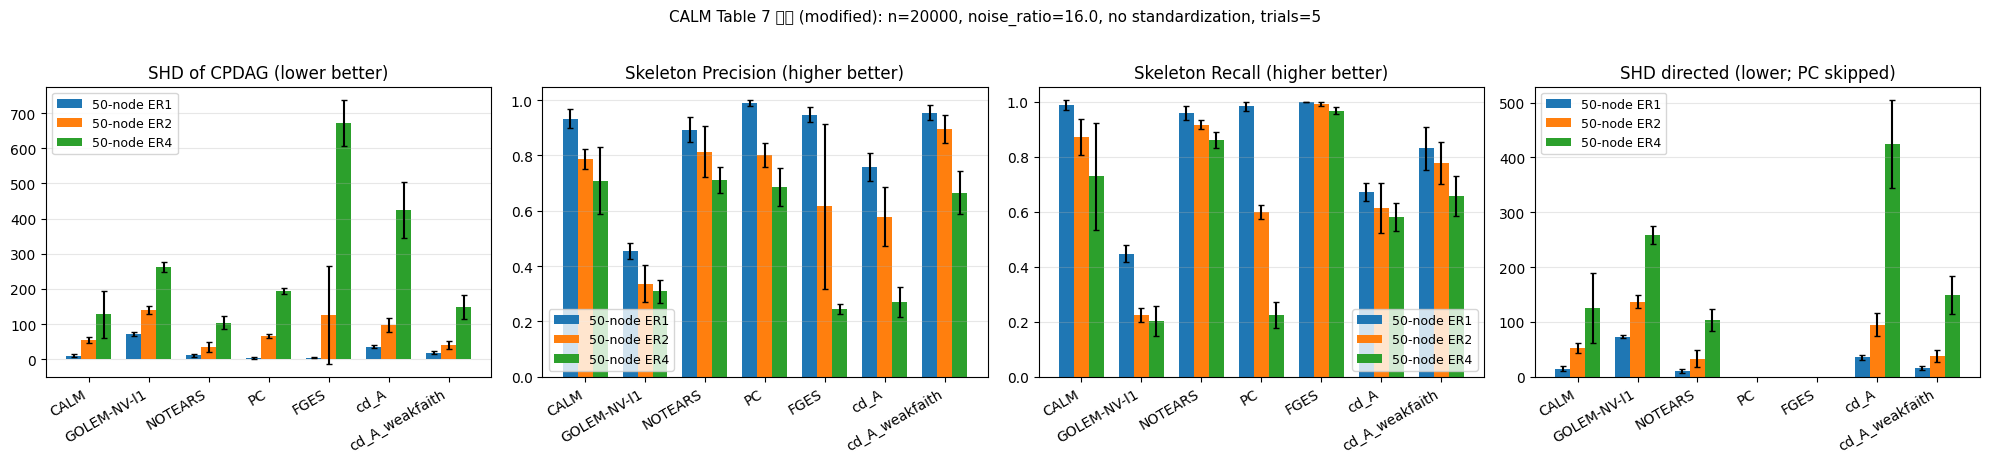

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
metrics = [
    ('cpdag_shd_mean', 'cpdag_shd_std', 'SHD of CPDAG (lower better)',          False),
    ('sk_p_mean',      'sk_p_std',      'Skeleton Precision (higher better)',   False),
    ('sk_r_mean',      'sk_r_std',      'Skeleton Recall (higher better)',      False),
    ('shd_mean',       'shd_std',       'SHD directed (lower; PC skipped)',     True),
]
x_pos = np.arange(len(ALGORITHM_ORDER))
width = 0.25

for ax, (mcol, scol, title, skip_pc) in zip(axes, metrics):
    for gi, label in enumerate(graph_order):
        sub = df_summary[df_summary['graph_label'] == label].set_index('algorithm').reindex(ALGORITHM_ORDER)
        # PC 在 SHD 上为 NaN，matplotlib 会自动留空，无需特殊处理
        ax.bar(x_pos + (gi - 1) * width, sub[mcol].values, width=width,
               yerr=sub[scol].values, label=label, capsize=2)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(ALGORITHM_ORDER, rotation=30, ha='right')
    ax.set_title(title)
    ax.grid(alpha=0.3, axis='y')
    ax.legend(fontsize=9)

fig.suptitle(
    f"CALM Table 7 复现 (modified): n={CFG['n_samples']}, "
    f"noise_ratio={CFG['noise_ratio']}, no standardization, trials={CFG['trials']}",
    fontsize=11, y=1.02,
)
plt.tight_layout()
plt.show()

## 9. 失败/跳过记录

In [ ]:
if skip_logs:
    df_skip = pd.DataFrame(skip_logs)
    display(df_skip)
else:
    print('所有 trial 均运行成功。')

所有 trial 均运行成功。
